# Retrieval 평가

- **입력**: `evaluation/dataset/goldset_final.json`
- **방법**: goldset의 `retrieval_info`(source/rank/score)를 활용해 ES 호출 없이 평가
- **Relevant 기준**: `final_grade >= 2` (grade 2=적합, 3=매우적합)
- **지표**: Hit@K, Recall@K, MRR@K, NDCG@K (K=5, 10, 20)
- **비교 대상**: BM25 / Dense / Hybrid
- **출력**: `evaluation/results/retrieval_metrics.png`

In [1]:
import os
os.chdir("/Users/shimsomin/Workplace/git_workspace/librAIan/backend")

import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

REPO_ROOT = Path("/Users/shimsomin/Workplace/git_workspace/librAIan")
sys.path.insert(0, str(REPO_ROOT / "evaluation" / "metrics"))
from metrics import hit_at_k, recall_at_k, mrr_at_k, ndcg_at_k

In [2]:
DATASET_DIR        = REPO_ROOT / "evaluation" / "dataset"
RESULTS_DIR        = REPO_ROOT / "evaluation" / "results"
RESULTS_DIR.mkdir(exist_ok=True)

GOLDSET_PATH       = DATASET_DIR / "goldset_final.json"
RELEVANT_THRESHOLD = 2        # final_grade >= 2 → relevant
K_VALUES           = [5, 10, 20]

print(f"GOLDSET_PATH: {GOLDSET_PATH}")
print(f"RESULTS_DIR:  {RESULTS_DIR}")

GOLDSET_PATH: /Users/shimsomin/Workplace/git_workspace/librAIan/evaluation/dataset/goldset_final.json
RESULTS_DIR:  /Users/shimsomin/Workplace/git_workspace/librAIan/evaluation/results


In [3]:
with open(GOLDSET_PATH, encoding="utf-8") as f:
    goldset = json.load(f)

print(f"goldset 항목 수: {len(goldset):,}")

# 시나리오 목록
from collections import Counter
qid_counts = Counter(b.get("query_id") for b in goldset)
print(f"시나리오 수: {len(qid_counts)}")
print(f"query_id 목록: {sorted(qid_counts.keys())}")

goldset 항목 수: 1,698
시나리오 수: 21
query_id 목록: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21']


## 시나리오별 Eval 구조 빌드

goldset의 `retrieval_info`에서 source/rank를 추출해 retriever별 ranked list를 구성한다.

In [4]:
eval_data = {}   # query_id → {relevant_isbns, bm25, dense, hybrid}

for book in goldset:
    qid  = book.get("query_id")
    isbn = book.get("isbn")
    if not qid or not isbn:
        continue

    if qid not in eval_data:
        eval_data[qid] = {"relevant_isbns": [], "bm25": [], "dense": [], "hybrid": []}

    if book.get("final_grade", -1) >= RELEVANT_THRESHOLD:
        eval_data[qid]["relevant_isbns"].append(isbn)

    for ri in book.get("retrieval_info", []):
        src  = ri.get("source")
        rank = ri.get("rank")
        if src in ("bm25", "dense", "hybrid") and rank is not None:
            eval_data[qid][src].append((rank, isbn))

# rank 기준 정렬 → ISBN 리스트
for qid in eval_data:
    for src in ("bm25", "dense", "hybrid"):
        eval_data[qid][src] = [isbn for _, isbn in sorted(eval_data[qid][src])]

# 시나리오별 통계
print(f"{'query_id':>10} {'relevant':>9} {'bm25':>6} {'dense':>6} {'hybrid':>7}")
print("-" * 45)
for qid in sorted(eval_data):
    d = eval_data[qid]
    print(f"{qid:>10} {len(d['relevant_isbns']):>9} {len(d['bm25']):>6} "
          f"{len(d['dense']):>6} {len(d['hybrid']):>7}")

  query_id  relevant   bm25  dense  hybrid
---------------------------------------------
       S01         7     40     39      39
       S02         6     40     40      40
       S03         0     40     40      40
       S04         9     40     40      40
       S05         3     40     40      40
       S06        29     40     39      39
       S07         9     39     39      39
       S08         3     40     40      40
       S09         9     40     40      40
       S10        27     40     38      39
       S11         6     40     40      40
       S12        40     40     38      38
       S13        11     40     40      40
       S14        10     40     40      40
       S15         2     40     40      40
       S16        13     40     40      40
       S17        22     38     38      38
       S18        34     39     37      37
       S19        37     40     40      40
       S20        12     40     39      39
       S21        18     40     40      40


## Retrieval 평가

In [5]:
def compute_retrieval_metrics(
    eval_data,
    retrievers=("bm25", "dense", "hybrid"),
    ks=K_VALUES,
):
    rows = []
    for qid, d in eval_data.items():
        rel = d["relevant_isbns"]
        if not rel:
            continue  # relevant 없는 시나리오 skip
        for src in retrievers:
            ranked = d[src]
            if not ranked:
                continue
            for k in ks:
                rows.append({
                    "query_id": qid,
                    "retriever": src,
                    "k": k,
                    "hit":    hit_at_k(rel, ranked, k),
                    "recall": recall_at_k(rel, ranked, k),
                    "mrr":    mrr_at_k(rel, ranked, k),
                    "ndcg":   ndcg_at_k(rel, ranked, k),
                })
    return pd.DataFrame(rows)


retrieval_df = compute_retrieval_metrics(eval_data)
print(f"총 {len(retrieval_df)}개 행 (시나리오 × retriever × K)")
retrieval_df.head(9)

총 180개 행 (시나리오 × retriever × K)


,query_id,retriever,k,hit,recall,mrr,ndcg
0,S05,bm25,5,0,0.000000,0.000,0.000000
1,S05,bm25,10,0,0.000000,0.000,0.000000
2,S05,bm25,20,0,0.000000,0.000,0.000000
3,S05,dense,5,0,0.000000,0.000,0.000000
4,S05,dense,10,1,1.000000,0.125,0.424960
5,S05,dense,20,1,1.000000,0.125,0.424960
6,S05,hybrid,5,1,0.333333,0.200,0.181542
7,S05,hybrid,10,1,0.333333,0.200,0.181542
8,S05,hybrid,20,1,0.333333,0.200,0.181542


In [6]:
# retriever × K 평균
summary = (
    retrieval_df
    .groupby(["retriever", "k"])[["hit", "recall", "mrr", "ndcg"]]
    .mean()
    .round(4)
)
print("[retriever × K 평균 성능]")
print(summary.to_string())

[retriever × K 평균 성능]
               hit  recall     mrr    ndcg
retriever k                               
bm25      5   0.70  0.0862  0.4225  0.2460
          10  0.80  0.1612  0.4350  0.2310
          20  0.85  0.2256  0.4378  0.2437
dense     5   0.75  0.1206  0.5600  0.3965
          10  0.90  0.2851  0.5805  0.4048
          20  0.95  0.4489  0.5847  0.4408
hybrid    5   0.75  0.1663  0.4975  0.3691
          10  0.90  0.2364  0.5168  0.3457
          20  0.95  0.3337  0.5213  0.3651


In [7]:
# 시나리오별 상세 (hybrid, K=10 기준)
per_query = (
    retrieval_df[
        (retrieval_df["retriever"] == "hybrid") &
        (retrieval_df["k"] == 10)
    ][["query_id", "hit", "recall", "mrr", "ndcg"]]
    .set_index("query_id")
    .sort_index()
)
print("[Hybrid @K=10 시나리오별 성능]")
print(per_query.to_string())

[Hybrid @K=10 시나리오별 성능]
          hit    recall       mrr      ndcg
query_id                                   
S01         1  0.285714  1.000000  0.448304
S02         0  0.000000  0.000000  0.000000
S04         1  0.333333  0.500000  0.344169
S05         1  0.333333  0.200000  0.181542
S06         1  0.137931  0.142857  0.272670
S07         1  0.666667  1.000000  0.763778
S08         1  0.333333  0.333333  0.234639
S09         1  0.111111  0.100000  0.067943
S10         1  0.148148  0.333333  0.353598
S11         1  0.333333  0.500000  0.321245
S12         1  0.125000  1.000000  0.642187
S13         1  0.272727  1.000000  0.432318
S14         1  0.400000  0.333333  0.332174
S15         0  0.000000  0.000000  0.000000
S16         1  0.461538  1.000000  0.727330
S17         1  0.227273  1.000000  0.514186
S18         1  0.117647  0.250000  0.298027
S19         1  0.162162  0.500000  0.552746
S20         1  0.166667  1.000000  0.283713
S21         1  0.111111  0.142857  0.142795


저장 완료: /Users/shimsomin/Workplace/git_workspace/librAIan/evaluation/results/retrieval_metrics.png


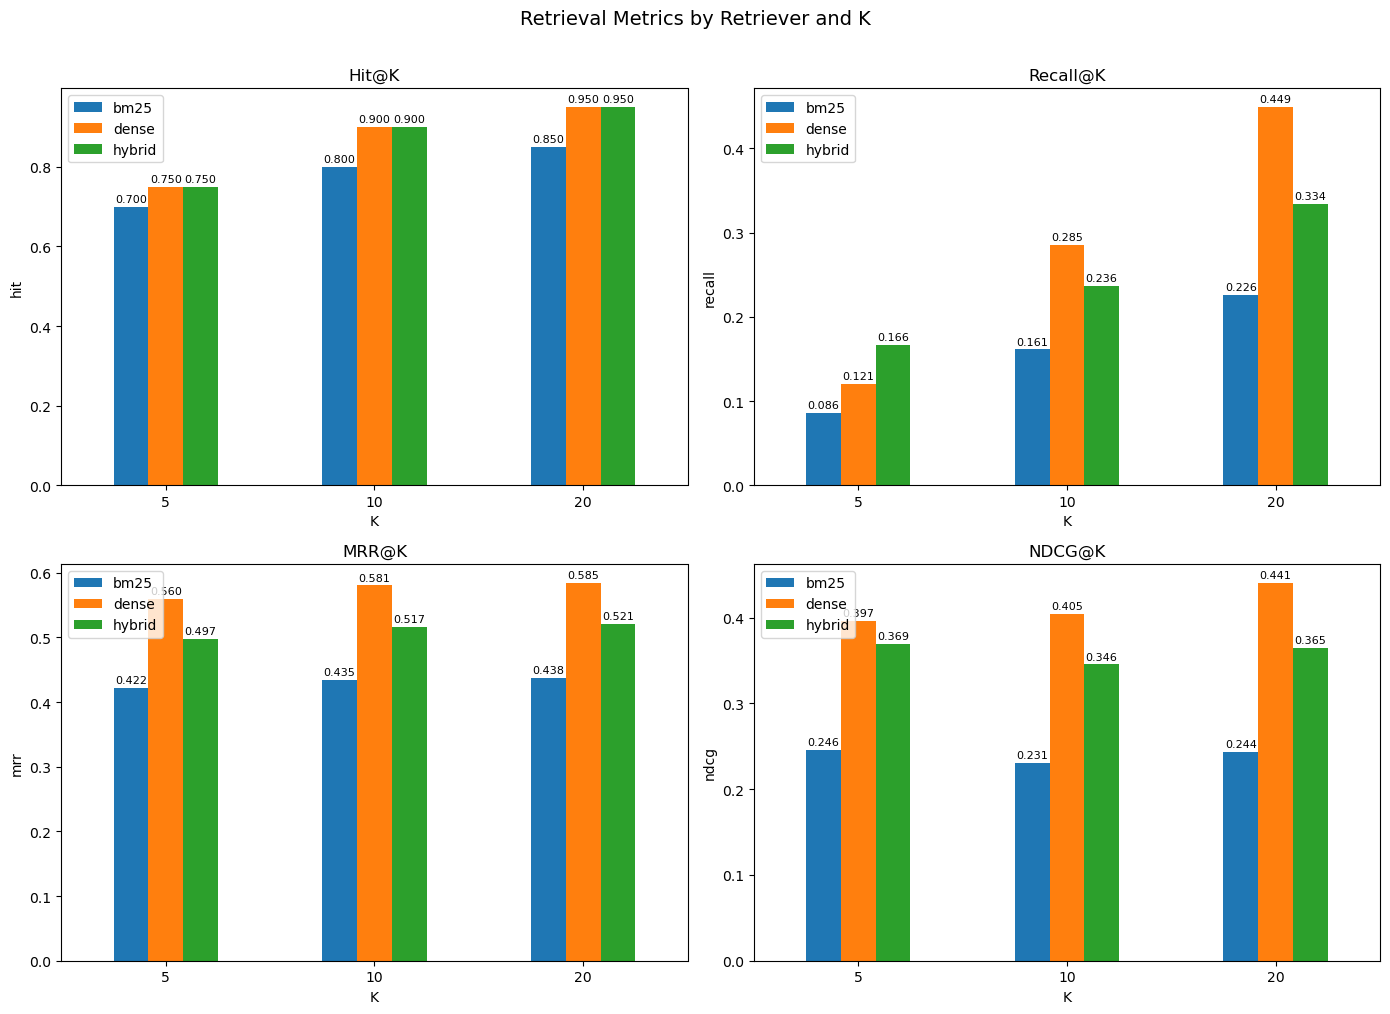

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Retrieval Metrics by Retriever and K", fontsize=14, y=1.01)

for ax, metric, title in zip(
    axes.flat,
    ["hit", "recall", "mrr", "ndcg"],
    ["Hit@K", "Recall@K", "MRR@K", "NDCG@K"],
):
    pivot = summary[metric].unstack("retriever")   # index=k, columns=retriever
    pivot.plot(kind="bar", ax=ax, title=title, rot=0)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.legend(loc="upper left")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
save_path = RESULTS_DIR / "retrieval_metrics.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"저장 완료: {save_path}")
plt.show()